<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer suppurted. Adjust the input and output path if nedded.

In [1]:
# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np

# Plot
import matplotlib.pyplot as plt

# TF-IDf
from sklearn.feature_extraction.text import TfidfVectorizer

# Graphs
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable

# Loading and Exporting

## Parameters

In [2]:
dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_3.gzip.parquet"  # file name
dataset_procced_date = "2026_01_08"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"

## Load Data

In [3]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
print(f"Running on local/cluster.\nLoading data from: {processed_dataset_path}")

# Load the parquet file
df = pd.read_parquet(processed_dataset_path / f"Topic_Ner_{file_name}")

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08


## Output

In [4]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Dataset collums

In [5]:
print(f"df shpe: {df.shape}")
print("")
print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shpe: (49925, 26)

**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic

In [6]:
account_id_col = "accountid"

# TF-IDF Score

## Entities

TF-IDF Using *sklearn*

In [7]:
def compute_entities_tfidf(df, entity_col, topic_col="BERTopic_topic"):
    """
    Compute TF-IDF over entities grouped by topic.
    Output shape: rows = entities, columns = topics.

    Args:
        df (pd.DataFrame): Contains [topic_col] and [entity_col] (list of entities).
        entity_col (str): Column with lists of entities per post.
        topic_col (str): Topic label column.

    Returns:
        pd.DataFrame: TF-IDF matrix (rows = entities, columns = topics).
    """

    # 1) Explode rows → (topic, entity)
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .astype({entity_col: str})
    )

    # 2) Build topic "documents"
    topic_docs_df = (
        df_exp.groupby(topic_col)[entity_col]
              .apply(lambda x: " ".join(x))
              .reset_index()
              .rename(columns={entity_col: "doc"})
    )

    # 3) TF-IDF where rows=topics, cols=entities
    vec = TfidfVectorizer(token_pattern=r"\S+")
    X = vec.fit_transform(topic_docs_df["doc"])

    topic_entity_df = pd.DataFrame(
        X.toarray(),
        index=topic_docs_df[topic_col].values,
        columns=vec.get_feature_names_out()
    )

    # 4) Transpose → rows=entities, columns=topics
    entity_topic_df = topic_entity_df.T

    return entity_topic_df

In [8]:
hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col="BERTopic_topic")
hashtags_tfidf_df.head()

,-1,0,1,2,3,4,5,6,7,8,...,128,129,130,131,132,133,134,135,136,137
09denoviembre,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0responsables,0.001322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000aday,0.006884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100aday,0.002440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100cancionesfavoritas,0.006610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids.
        topic_is (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [10]:
top_entities = get_top_entities(hashtags_tfidf_df, topic_id = -1, top_n=10)
print(top_entities)

['quito', 'ecuador', 'rt', 'casting', 'guayaquil', 'sex', 'uio', 'ff', 'venezuela', 'news']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [11]:
# prams
topic_col = "BERTopic_topic"
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]

In [12]:
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    out_col: str = "post_tfidf",
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns.

    Updates df[out_col].
    The TF-IDF score of a posts is the score of its entities in its topic, across all entity columns.

    Args:
        df: Input DataFrame (modified in place).
        topic_col: Column containing topic identifiers.
        entity_cols_lst: List of entity-list columns (each cell is list-like or None).
        out_col: Output column name.

    Returns:
        None.
    """
    df[out_col] = 0.0

    for entity_col in entity_cols_lst:
        # rows=entities, columns=topics
        entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)

        # Build a fast lookup: (entity, topic) -> tfidf
        tfidf_dict = entities_tfidf_df.stack().to_dict()

        for idx, row in df.iterrows():
            topic = row[topic_col]
            ents = row[entity_col]
            if ents is None or len(ents) == 0:
                score = 0.0
            else:
                score = float(sum(tfidf_dict.get((e, topic), 0.0) for e in ents))
            df.at[idx, out_col] += score

In [13]:
compute_post_tfidf(df, topic_col, entity_cols_lst)
df[["post_text", "post_tfidf", topic_col]].head()

,post_text,post_tfidf,BERTopic_topic
0,"Queda prohibido no sonreir a los problemas, no...",0.054582,2
1,"Te encontraras con gente hipócrita, con amigos...",0.000000,2
2,Aventarle un diccionario a alguien en la cabez...,0.000000,-1
3,"Suena mi alarma del celu, tendre que levantarm...",0.137944,61
4,En el mar la vida es mas sabrosa 8' @5b3c3e3a2...,0.072041,-1


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [14]:
def compute_author_tfidf_to_df(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    out_col: str = "topic_author_tfidf",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        out_col: Output column added to df.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.

    Returns:
        author_topic_tfidf: Author × topic TF-IDF matrix.
    """

    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_tfidf = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    df[out_col] = df.apply(
        # Pandas aligns by row index = author.
        lambda row: author_topic_tfidf.loc[row[author_col], row[topic_col]],
        axis=1,
    )

    return author_topic_tfidf

In [15]:
author_topic_tfidf = compute_author_tfidf_to_df(df, topic_col = topic_col)
author_topic_tfidf.head()

BERTopic_topic,-1,0,1,2,3,4,5,6,7,8,...,128,129,130,131,132,133,134,135,136,137
accountid,,,,,,,,,,,,,,,,,,,,,
004a86b22c65f5f884e522150b53f7e7d5ff5fc084,0.201149,0.000000,0.000000,0.0,0.000000,0.183865,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
007cc60722e55936290c66a0e58fc5ce7dfccd94fe,0.413299,0.310850,0.037217,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00b90ffc178d3cb657d75514106cccef10d9735d9a,1.788482,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00d308b4e7797c089c0654b2c83ed906b0d240fbf1,0.270895,0.080131,0.000000,0.0,3.144282,1.139089,1.916597,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
018948852bcaa0845f11ccfceeaea649eb496e0624,0.000000,0.000000,0.000000,0.0,0.241510,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Key Authors

In [16]:
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 20,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """
    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [17]:
get_topic_top_authors(df, topic=1, topic_col = topic_col)

There are 20 unique key authors in topic 1.


{'1b3972f155cfa2073bd97cfbced79a7baeb57289d8',
 '1cd4419aa148609896d5d032040437641c95d6f10c',
 '3929be51a15269c1e116035bac575aea62836f4274',
 '40a927417ec7dd26939b28d3e7eeb83eddd908f1c3',
 '4155a4e4f67b253c06528cb0a01d0851e1bf5e8923',
 '4a08f9f3e1b73d62e982f899cdfb644e2101bd28a4',
 '50a1a60bebbb6f9e1ebec9c8d81d395b55fb59b91f',
 '71cc57155d061d447c2c65756c7dfd6873e403a097',
 '980fea2e441caa09977978e391649fb09102c334f9',
 '9c37577f2e475fbe93c1a63361d544e00959108465',
 'a3037b35b26f5bf5a34cd457ac57a99323bc792c41',
 'ac9e346d9d35803a3f4536d6352ccc396c6f4afa58',
 'c9c1360b6ef93bedaf7a0d50f065b3bcd223e00c52',
 'cc33b9486488402f15f578b574059f7e06a9b86e93',
 'd14885d7a2a0521d0b18e5502b7b5969adf92180f6',
 'd1ca7dd2cccf52478ed3cbe1425088fc0cd701250f',
 'e49033d6511f0019d0c645047481b4080e761bc37f',
 'f1efcaf76e159b036f41c5663f48562e30fb011ea1',
 'f60fc9169473c409635b986e4c142dcaf27bf7e1c4',
 'fb6b2cbec022dff73cfc930d28c11886632dd0051b'}

In [18]:
def get_all_topics_key_authors(
    df: pd.DataFrame,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 10,
) -> set:
    """Return a set of authors that are top-n in at least one topic.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        n: Top-n authors per topic.

    Returns:
        pd.DataFrame: DataFrame of key authors per topic [topic_col, author_col, score_col].
        set: Authors that appear in the top-n of any topic.
    """
    all_topics_key_authors_df = (
        df[[topic_col, author_col, score_col]]
        .dropna(subset=[topic_col, author_col, score_col])
        .drop_duplicates([topic_col, author_col])   # no aggregation
        .sort_values([topic_col, score_col], ascending=[True, False])
        .groupby(topic_col)
        .head(n)
        .reset_index(drop=True)
    )

    print("Sample of all topic key authors:")
    print("Note: authors may appear multiple times for different topics.")
    display(all_topics_key_authors_df.sample(n=10))

    all_topic_top_authors_number = all_topics_key_authors_df.drop_duplicates(subset=[author_col]).shape[0]
    print(f"There are {all_topic_top_authors_number} unique key authors in all topics.")
    
    return all_topics_key_authors_df, set(all_topics_key_authors_df[author_col])

In [19]:
all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(df = df, topic_col = topic_col, n = 5)

Sample of all topic key authors:
Note: authors may appear multiple times for different topics.


,BERTopic_topic,accountid,topic_author_tfidf
354,69,9f0962293f848362295c489669dc596ca37eea680b,4.174779
284,55,5f6a7293776be3e21417e0c24f63fbf60afaf4f80b,3.244947
2,-1,c24932489666a76ef9f18c80417080822e5e330da1,236.909466
602,122,07ecbffa2c5e63b11b159b0b5e9e17dbd134d8a886,11.544720
258,50,ebba90cb35a8703037e61d50cef9f39832f718fd8f,2.241626
11,1,c9c1360b6ef93bedaf7a0d50f065b3bcd223e00c52,23.672194
422,83,40a927417ec7dd26939b28d3e7eeb83eddd908f1c3,4.414699
660,133,ff48a3b78edfed197300e738382086ffb7c83940d6,1.363197
633,128,61ae7a335b1677254c23c9c15774861b70cd279be8,3.291110
658,133,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,2.369688


There are 413 unique key authors in all topics.


# IO Authors

In [20]:
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"There are {len(io_authors)} io authors.")

    return io_authors

In [21]:
io_authors_set = get_io_authors_by_ratio(df)

There are 13 io authors.


# Key and IO Authors Summary

In [22]:
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set)}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set)}\n"
        f"Number of key authors: {len(all_topics_key_authors_set)}\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key)}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [23]:
save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, output_path = folder_output_path)

### io_key_summary ###

Number of all authors: 1099

Number of IO authors: 13
Number of key authors: 413

Number of authors that are both IO and key: 10
76.9% of IO authors are also key authors

Saved summary to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08/io_key_authors_summary.txt


# Networkx Graphs

## Parameters

In [24]:
account_relations = [
    ("accountid", "in_reply_to_accountid"),
    ("accountid", "account_mentions"),
    ("accountid", "reposted_accountid"),
]

## Build Bipartite Account ↔ Account Graph

In [25]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    topic_col: str = "BERTopic_topic",
    io_authors: set | None = None,
) -> None:
    """Add weighted edges to a graph and annotate author nodes.

    This builds edges from co-occurrence counts of (src, dst) pairs.
    Edge weights are incremented by `weight` for each co-occurrence.
    Annotates nodes with: (optional)
        * io_author: 1 if author in `io_authors`, else 0
        * score: aggregated author-topic score 
        * participan_at_topics: list of topics the author is active in
      

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_df: Optional DataFrame with author-topic metadata.
        author_col: Column in `all_topics_key_authors_df` containing author IDs.
        score_col: Column in `all_topics_key_authors_df` containing author-topic score.
        topic_col: Column in `all_topics_key_authors_df` containing topic label.
        io_authors: Optional set of IO-labeled authors.

    Returns:
        None
    """

    # make pairs of src-dst
    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # author_meta: (score_map, topics_map)
    author_meta = None
    if all_topics_key_authors_df is not None:
        tmp = all_topics_key_authors_df[[author_col, score_col, topic_col]].dropna()
        tmp[author_col] = tmp[author_col].astype(str)

        key = set(tmp[author_col].unique())
        pairs = pairs[pairs[src_col].isin(key) & pairs[dst_col].isin(key)]

        # score per author
        author_sum_score_map: dict[str, float] = tmp.groupby(author_col)[score_col].sum().to_dict()
        # Topics per author, sorted by score descending (highest-score topics first)
        author_topics_map : dict[str, list] = (
            tmp.sort_values([author_col, score_col], ascending=[True, False])
            .groupby(author_col)[topic_col]
            .apply(list)
            .to_dict()
        )
        
        author_meta = (author_sum_score_map , author_topics_map)

    # io_author set
    if io_authors is not None:
        io_authors = set(map(str, io_authors))


    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count")
    print("pairs.value_counts head:")
    display(counts.head())

    for row in counts.itertuples(index=False):
        src = getattr(row, src_col)
        dst = getattr(row, dst_col)
        w = int(row.count) * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            continue # skip to next row, dont update labels again

        # add the edge (automatically add nodes if needed)
        G.add_edge(src, dst, weight=w)
            
        # add lables
        for author in [src, dst]:
            # add io_author label
            if io_authors is not None:
                G.nodes[author]["io_author"] = int(author in io_authors)
            # add author meta
            if author_meta is not None:

                G.nodes[author][f"all_topics_scores_sum"] = author_meta[0][author]

                author_topics = author_meta[1][author]
                G.nodes[author]["highest_score_topic"] = author_topics[0] # the topic with the highest score
                G.nodes[author]["participan_at_topics"] = ",".join(map(str, author_topics))
                
    return None

In [26]:
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    io_authors: set | None = None,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    output_path: Path | None = None,
    graph_name: str = "accounts_graph",
    directed_graphs = True,
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_df: Optional filter for key authors onlya (author-topic metadata).
        output_path: If provided, writes `<output_path>/<graph_name>.gexf`.
        graph_name: Graph name (also used as output filename stem).
        directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).


    Returns:
        nx.DiGraph: The constructed accounts graph.
    """
    # create graph
    if directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = graph_name

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if all_topics_key_authors_set is None:
        print("Warning: all_topics_key_authors_set is None. No filtering will be applied.")

    # Add nodes and edges
    for src_col, dst_col in account_relations:
        print(f"[build_accounts_graph] Now adding edges of {dst_col}")
        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_df=all_topics_key_authors_df,
            io_authors=io_authors,
        )

    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{graph_name}.gexf"
        nx.write_gexf(G, graph_output_path)
        print(f"Saved graph to: {graph_output_path}")

    return G

In [27]:
G_accounts = build_accounts_graph(
    df=df,
    account_relations=account_relations,
    io_authors=io_authors_set,
    all_topics_key_authors_df=all_topics_key_authors_df,
    output_path=folder_output_path,
    graph_name="accounts_graph",
)

[build_accounts_graph] Now adding edges of in_reply_to_accountid
pairs.value_counts head:


,accountid,in_reply_to_accountid,count
0,1ab9531749792f126aeb0cde29e0d4628293ff2326,0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,95
1,71cc57155d061d447c2c65756c7dfd6873e403a097,f72876e465be073b329ab221a21558f99a6535793b,5
2,687b0b37014530e5f2c0b33d4483ac0ac0081b3f56,f72876e465be073b329ab221a21558f99a6535793b,3
3,71cc57155d061d447c2c65756c7dfd6873e403a097,2c3dee38f28293938b383df4d03b649c7fb2a3bf19,2
4,71cc57155d061d447c2c65756c7dfd6873e403a097,6cfdf644167e5ebd41a63b4ea16d8c56a20f82cbaf,2


[build_accounts_graph] Now adding edges of account_mentions
pairs.value_counts head:


,accountid,account_mentions,count
0,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,6cfdf644167e5ebd41a63b4ea16d8c56a20f82cbaf,105
1,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,f72876e465be073b329ab221a21558f99a6535793b,70
2,f1efcaf76e159b036f41c5663f48562e30fb011ea1,18788ec9289d4841b713bdbdee32c9d3d42ccecf76,43
3,71cc57155d061d447c2c65756c7dfd6873e403a097,f72876e465be073b329ab221a21558f99a6535793b,40
4,40a927417ec7dd26939b28d3e7eeb83eddd908f1c3,0974a37fdd7ca5cfd94bba466789d706c8d3c17edb,37


[build_accounts_graph] Now adding edges of reposted_accountid
pairs.value_counts head:


,accountid,reposted_accountid,count
0,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,6cfdf644167e5ebd41a63b4ea16d8c56a20f82cbaf,89
1,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,f72876e465be073b329ab221a21558f99a6535793b,35
2,40a927417ec7dd26939b28d3e7eeb83eddd908f1c3,0974a37fdd7ca5cfd94bba466789d706c8d3c17edb,29
3,1b3972f155cfa2073bd97cfbced79a7baeb57289d8,e358899cb3fec2a70dbd23eb2634f87cd6baf46458,17
4,71cc57155d061d447c2c65756c7dfd6873e403a097,18788ec9289d4841b713bdbdee32c9d3d42ccecf76,13


Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08/accounts_graph.gexf


## Plot Accounts Graph

In [28]:
def plot_accounts_graph(
    G: nx.Graph,
    folder_output_path: str | Path | None = None,
    graph_name: str = "accounts_graph",
    figsize: tuple = (12, 12),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
):
    """Plot a NetworkX graph and highlight IO authors.
    
    Args:
        G: Input NetworkX graph with node attribute 'io_author' (1 for IO, 0 for non-IO).
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: Base name for the saved plot file.
        figsize: Figure size for the plot.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX. Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
    """
    if key_authors is not None:
        key_authors = set(map(str, key_authors))
        G_plot = G.subgraph(key_authors)
    else:
        G_plot = G

    n_nodes = G_plot.number_of_nodes()
    n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
    n_legitimate = n_nodes - n_io
    
    print(f"Plotting graph with {n_nodes} nodes: {n_io} IO authors, {n_legitimate} legitimate authors")
    
    plt.figure(figsize=figsize)
    
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G_plot, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G_plot)
    elif layout == "random":
        pos = nx.random_layout(G_plot, seed=42)
    elif layout == "shell":
        pos = nx.shell_layout(G_plot)
    elif layout == "spectral":
        pos = nx.spectral_layout(G_plot)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G_plot)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    node_colors = [
        "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
        for n in G_plot.nodes
    ]

    nx.draw(
        G_plot,
        pos,
        node_size=30,
        node_color=node_colors,
        edge_color="gray",
        width=0.5,
        alpha=0.8,
        with_labels=False,
    )

    legend_elements = [
        mpatches.Patch(color="steelblue", label=f"Non-IO author ({n_legitimate} nodes)"),
        mpatches.Patch(color="red", label=f"IO author ({n_io} nodes)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=10)

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()


Plotting graph with 93 nodes: 5 IO authors, 88 legitimate authors


Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08/accounts_graph_spring.png


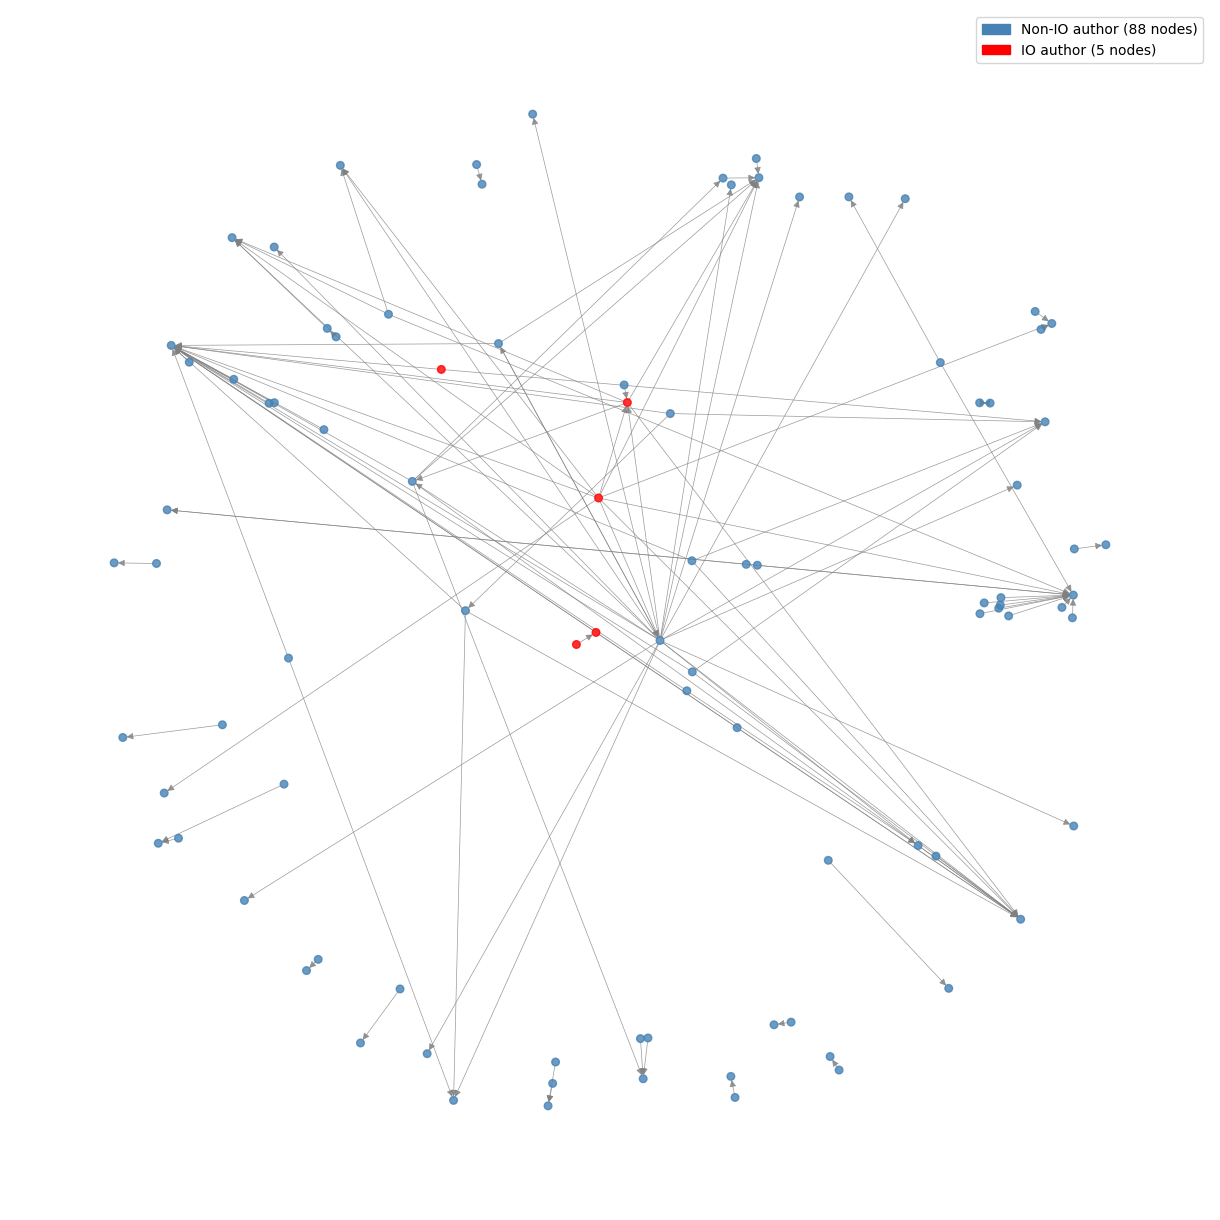

In [29]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, layout="spring")

# IO Indicators

e.g, centralities, core number

## Compute Indicators

In [30]:
def compute_indicators(G: nx.Graph, output_folder_path: str | Path | None = None) -> pd.DataFrame:
    """Compute multiple graph centralities.

    Returns a DataFrame indexed by author/node with:
      - degree
      - betweenness
      - closeness
      - eigenvector
      - pagerank
      - kcore (core number)
      - sum tfidf score

    Args:
        G: NetworkX graph

    Returns:
        centralities_df: Centrality measures per node.
    """
    # Degree centrality
    print("Calculating: degree_centrality")
    degree = nx.degree_centrality(G)
    

    # Betweenness centrality
    print("Calculating: betweenness_centrality")
    betweenness = nx.betweenness_centrality(G, normalized=True)
    

    # Closeness centrality
    print("Calculating: closeness_centrality")
    closeness = nx.closeness_centrality(G)

    # Harmonic centrality
    print("Calculating: harmonic_centrality")
    harmonic = nx.harmonic_centrality(G)

    # Load centrality
    print("Calculating: load_centrality")
    load = nx.load_centrality(G, normalized=True)

    # Eigenvector centrality
    print("Calculating: eigenvector_centrality")
    eigen = nx.eigenvector_centrality(G, max_iter=2000)
    

    # PageRank
    print("Calculating: pagerank")
    pagerank = nx.pagerank(G)

    # Clustering
    print("Calculating: clustering")
    clustering = nx.clustering(G)


    # K-core number
    print("Calculating: core_number")
    kcore = nx.core_number(G)

    # sum tfidf score
    print("Calculating: all_topics_scores_sum")
    all_topics_scores_sum: dict[str, float] = {
    node: G.nodes[node]["all_topics_scores_sum"]
    for node in G.nodes
}

    # Build DataFrame
    node_indicators_df = pd.DataFrame(
        {
            "degree_centrality": degree,
            "betweenness_centrality": betweenness,
            "closeness_centrality": closeness,
            "harmonic_centrality": harmonic,
            "eigenvector_centrality": eigen,
            "load_centrality": load,
            "pagerank": pagerank,
            "kcore": kcore,
            "clustering": clustering,
            "all_topics_scores_sum": all_topics_scores_sum,
        }
    )

    node_indicators_df.index.name = "accountid"


    if output_folder_path is not None:
        node_indicators_df_path = Path(output_folder_path) / "node_centralities.parquet"
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")
        print(f"node_indicators_df is saved to: {node_indicators_df_path}")


    return node_indicators_df

In [31]:
node_indicators_df = compute_indicators(G_accounts)
node_indicators_df.head()

Calculating: degree_centrality
Calculating: betweenness_centrality
Calculating: closeness_centrality
Calculating: harmonic_centrality
Calculating: load_centrality
Calculating: eigenvector_centrality
Calculating: pagerank
Calculating: clustering
Calculating: core_number
Calculating: all_topics_scores_sum


,degree_centrality,betweenness_centrality,closeness_centrality,harmonic_centrality,eigenvector_centrality,load_centrality,pagerank,kcore,clustering,all_topics_scores_sum
accountid,,,,,,,,,,
1ab9531749792f126aeb0cde29e0d4628293ff2326,0.010870,0.000000,0.000000,0.0,1.729964e-09,0.000000,0.006412,1,0.000000,226.707785
0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,0.021739,0.000119,0.010870,1.0,4.497907e-08,0.000119,0.011863,1,0.000000,5.262637
71cc57155d061d447c2c65756c7dfd6873e403a097,0.108696,0.000000,0.000000,0.0,1.729964e-09,0.000000,0.006412,4,0.111111,34.710885
f72876e465be073b329ab221a21558f99a6535793b,0.206522,0.000000,0.208412,20.0,4.353697e-01,0.000000,0.070511,4,0.023392,44.773735
687b0b37014530e5f2c0b33d4483ac0ac0081b3f56,0.043478,0.000239,0.010870,1.0,4.497907e-08,0.000239,0.007191,3,0.083333,11.516453


## Z-Score

In [32]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [33]:
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [34]:
node_indicators_zscore_df = compute_zscore(node_indicators_df)
print("#### zscore ####")
node_indicators_zscore_df.head()

#### zscore ####


,degree_centrality,betweenness_centrality,closeness_centrality,harmonic_centrality,eigenvector_centrality,load_centrality,pagerank,kcore,clustering,all_topics_scores_sum
accountid,,,,,,,,,,
1ab9531749792f126aeb0cde29e0d4628293ff2326,-0.425790,-0.168877,-0.491716,-0.496410,-0.413644,-0.168877,-0.399866,-0.592134,-0.331334,0.916071
0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,-0.136750,0.101909,-0.142727,-0.166652,-0.413644,0.101909,0.102291,-0.592134,-0.331334,-0.501428
71cc57155d061d447c2c65756c7dfd6873e403a097,2.175571,-0.168877,-0.491716,-0.496410,-0.413644,-0.168877,-0.399866,2.584892,1.051018,-0.312926
f72876e465be073b329ab221a21558f99a6535793b,4.776933,-0.168877,6.199762,6.098754,4.129923,-0.168877,5.505318,2.584892,-0.040312,-0.248512
687b0b37014530e5f2c0b33d4483ac0ac0081b3f56,0.441330,0.372694,-0.142727,-0.166652,-0.413644,0.372694,-0.328129,1.525883,0.705430,-0.461396


## Account Indicators Summery

In [35]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [36]:
suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


show_account_indicators(
    accountid = suspect_accountid,
    node_indicators_df = node_indicators_df,
    node_indicators_zscore_df = node_indicators_zscore_df,
)

Account ID: 6c3aa869ed92672cdd48217644c1e59c29f8175a1d


,indicator,value,z_score
0,degree_centrality,0.011,-0.43
1,betweenness_centrality,0.000,-0.17
2,closeness_centrality,0.000,-0.49
3,harmonic_centrality,0.000,-0.50
4,eigenvector_centrality,0.000,-0.41
5,load_centrality,0.000,-0.17
6,pagerank,0.006,-0.40
7,kcore,1.000,-0.59
8,clustering,0.000,-0.33
9,all_topics_scores_sum,88.319,0.03


## Information Gain

In [39]:
def compute_centrality_information_gain(
    node_centralities_df: pd.DataFrame,
    io_authors: set,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_centralities_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    authors = node_centralities_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_centralities_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_centralities_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    return mi_series

In [ ]:
mi_series = compute_centrality_information_gain(node_indicators_df, io_authors_set)

## Plot

### Indicators Information Gain

In [64]:
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "centrality_information_gain.png",
    titel: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain (mutual information)")
    plt.xlabel("Centrality feature")
    plt.title(titel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08/centrality_information_gain.png


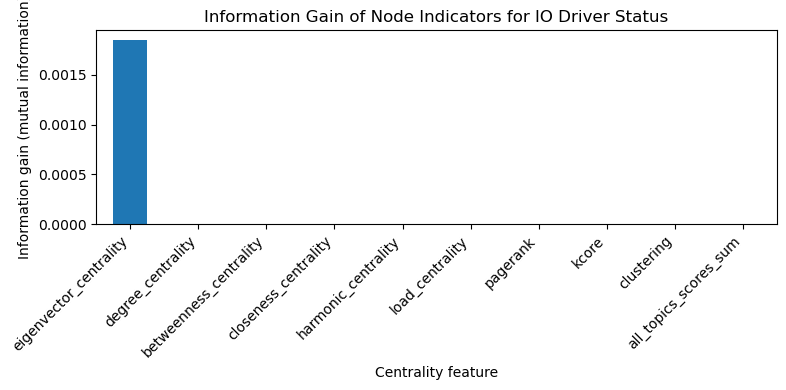

In [66]:
plot_indicators_information_gain(mi_series, folder_output_path)

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_3/2026_01_08/centrality_information_gain.png


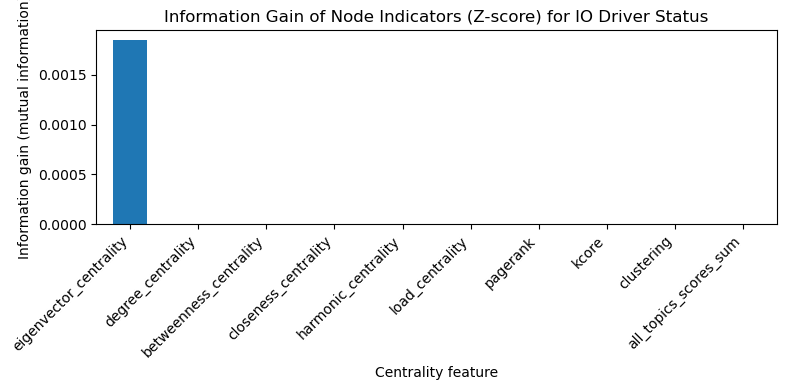

In [65]:

z_score_mi_series = compute_centrality_information_gain(node_indicators_zscore_df, io_authors_set)
plot_indicators_information_gain(z_score_mi_series, folder_output_path, titel = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

### Distributions

In [61]:
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of centrality features for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "centralities_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

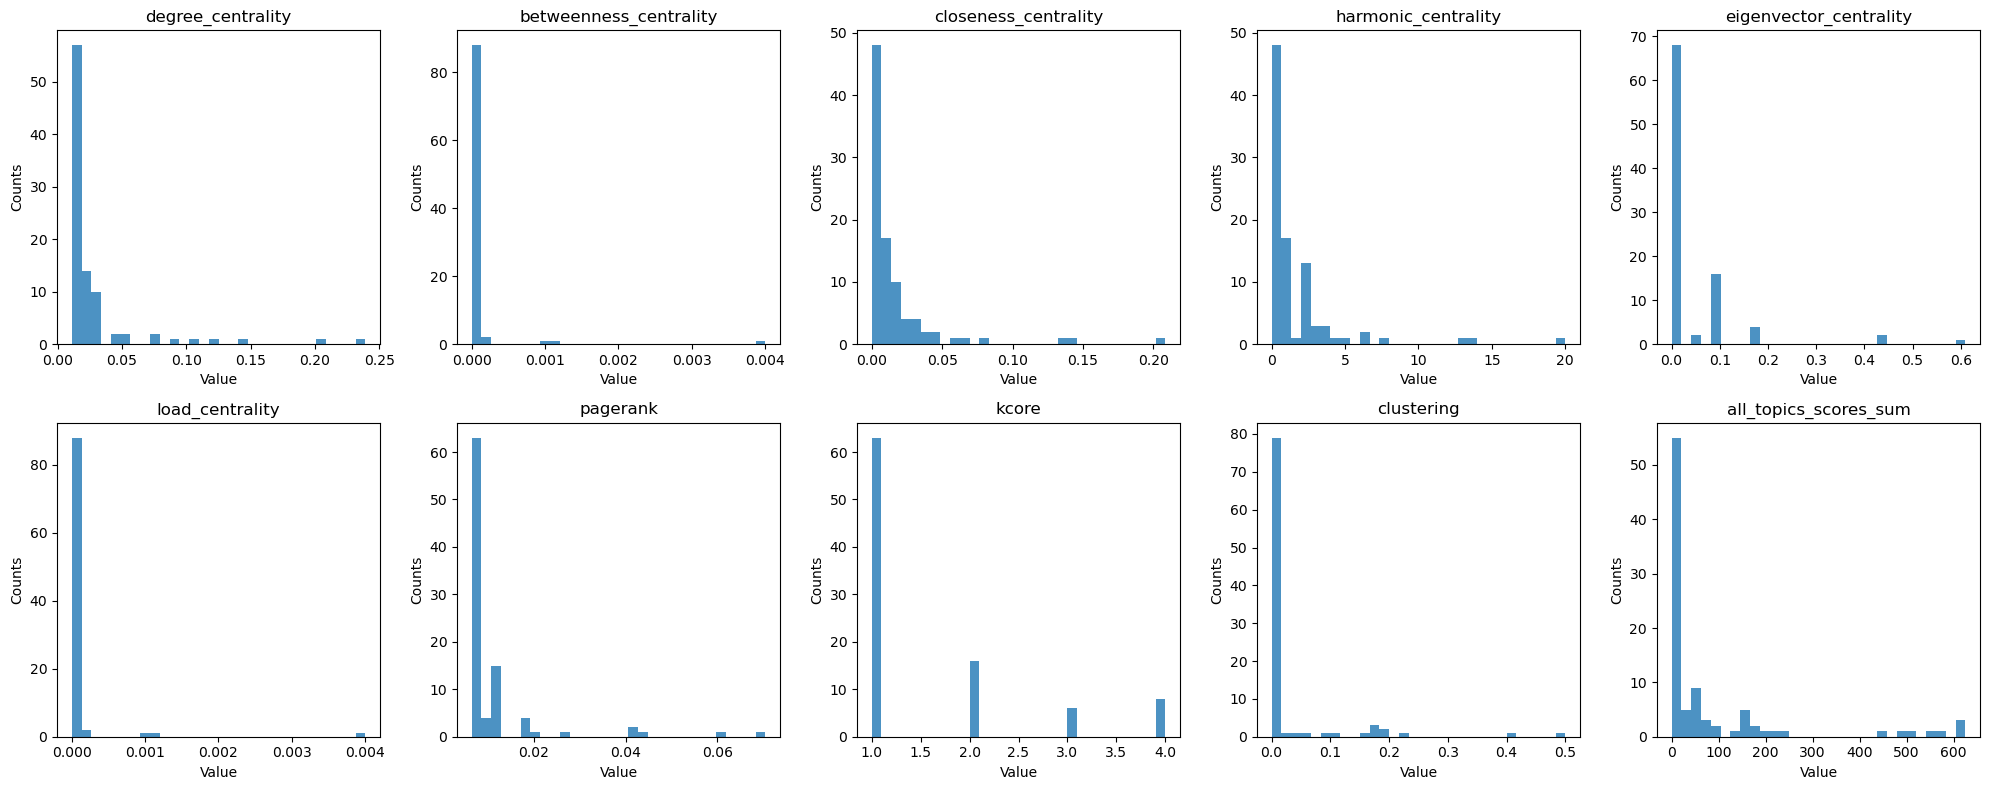

In [62]:
plot_indicators_distributions(node_indicators_df)

### Boxplots

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype


def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 2 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    plt.close()

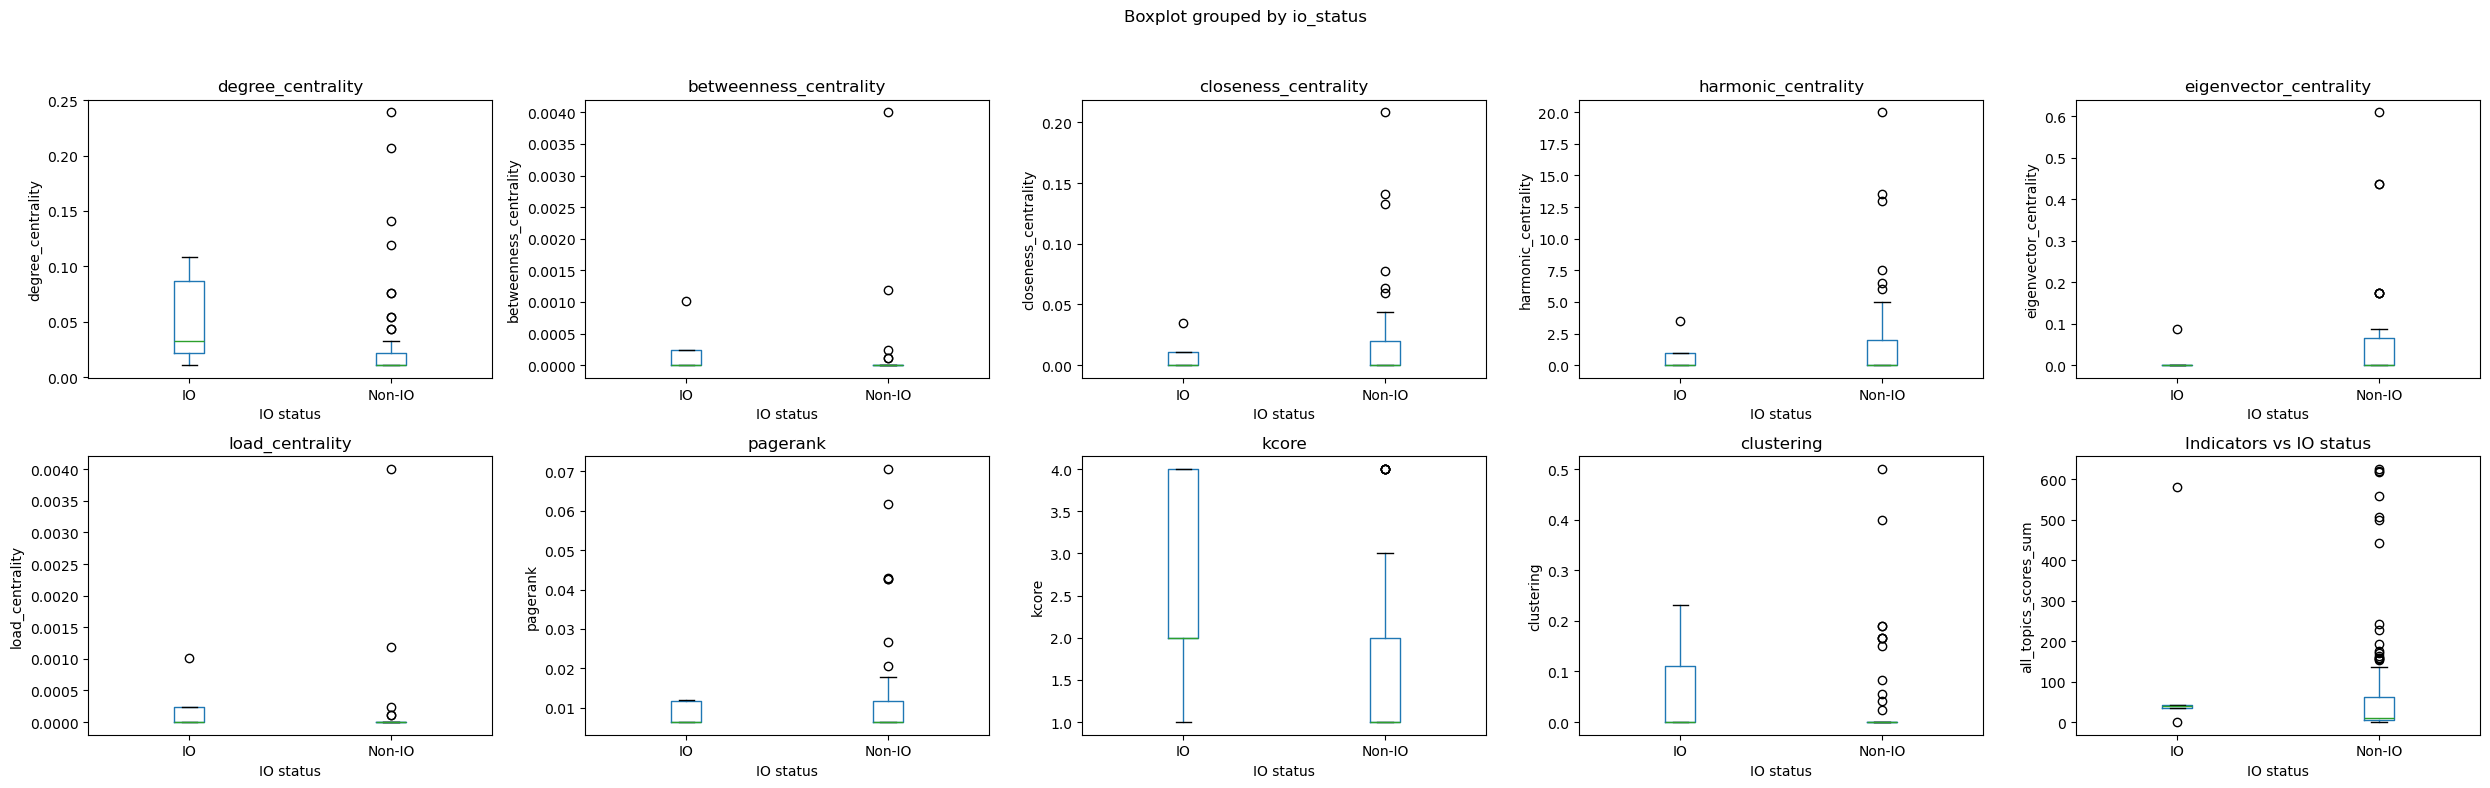

In [59]:
plot_indicator_boxplots(node_indicators_df, io_authors_set)

# Parameter Sweep: Information Gain Analysis

This section implements functions to run key_authors_graph with different min_topic_size and top_n values, compute total information gain, and visualize results.